In [1]:

import numpy as np

# We exploit symmetry:
# - Choose any index as T (set to 5) and S = {0..4}.
# - Rotation phi and permutation m do not change pairwise dot statistics.
# - Biases: optimal to use one shared b_S for S and one b_T for T.
# - b_T optimizes independently with W_T=0, giving b_T = 1/12 and H_T = 0.875.
# We then minimize over only two parameters: l >= 0 and b_S in R.

def build_W(l):
    W = np.zeros((2, 6), dtype=float)
    angles = 2 * np.pi * np.arange(5) / 5.0
    W[:, :5] = l * np.vstack((np.cos(angles), np.sin(angles)))
    # column 5 stays zero (index 5 is T)
    return W

def compute_H(l, bS, bT=1.0/12.0):
    W = build_W(l)
    G = W.T @ W
    norms = np.diag(G)
    b = np.array([bS]*5 + [bT], dtype=float)
    H = 0.0
    n = 6
    for i in range(n):
        bi = b[i]
        wi2 = norms[i]
        Ni = (1.0 - wi2)**2 - 3.0*(1.0 - wi2)*bi + 3.0*bi*bi
        if bi <= 0:
            # H_i^-
            term = 0.0
            # sum over j != i for P_{i,j}
            for j in range(n):
                if j == i:
                    continue
                gij = G[i, j]
                if (gij > 0.0) and (-gij <= bi <= 0.0):
                    term += ((gij + bi)**3) / gij
            Pi = (wi2 > 0.0) and (-wi2 <= bi <= 0.0)
            if Pi:
                term += bi**3 / (wi2**2) + bi**3 / wi2
                term += Ni
            else:
                term += 1.0
            H += term
        else:
            # H_i^+
            term = 0.0
            # default polynomial sum over j != i
            default_sum = 0.0
            for j in range(n):
                if j == i:
                    continue
                gij = G[i, j]
                default_sum += (gij**2 + 3.0*gij*bi + 3.0*bi*bi)
            # replace for Q_{i,j}
            adjust = 0.0
            for j in range(n):
                if j == i:
                    continue
                gij = G[i, j]
                if (-gij > bi) and (bi > 0.0):
                    adjust += (-(gij**2 + 3.0*gij*bi + 3.0*bi*bi)) + (-bi**3 / gij)
            term += default_sum + adjust
            term += Ni
            H += term
    return H

def loss_from_H(H):
    return H / 18.0

# Optimize over l and bS with bT fixed at 1/12
def optimize():
    best = (np.inf, None, None)
    # Stage 1 coarse grid
    l_vals = np.linspace(0.0, 2.0, 201)
    b_vals = np.linspace(-1.5, 1.5, 601)
    for l in l_vals:
        for bS in b_vals:
            H = compute_H(l, bS, bT=1.0/12.0)
            L = loss_from_H(H)
            if L < best[0]:
                best = (L, l, bS)
    # Stage 2 refine grid around the best
    L_best, l_c, b_c = best
    l_min = max(0.0, l_c - 0.2)
    l_max = l_c + 0.2
    b_min = b_c - 0.3
    b_max = b_c + 0.3
    l_vals = np.linspace(l_min, l_max, 401)
    b_vals = np.linspace(b_min, b_max, 801)
    for l in l_vals:
        for bS in b_vals:
            H = compute_H(l, bS, bT=1.0/12.0)
            L = loss_from_H(H)
            if L < best[0]:
                best = (L, l, bS)
    return best[0]

final_loss = optimize()
print(f"{final_loss:.4f}")

0.0618


In [ ]:
Think smart and use symmetries to reduce the problem dimensionality. Please first reason what the minima number of symmetries is in which the problem works. If it is more than 3 paramters, reason again.
please write python code only using numpy to do so and return the final loss as a number to 4 decimal places!

In [1]:
import numpy as np

# We exploit symmetries:
# - Choose S = {0,1,2,3,4}, T = {5}
# - Rotation phi and bijection m are irrelevant due to rotational symmetry of a regular 5-gon
# - All five nonzero columns share the same norm ell and angles differ by 2*pi/5
# - By symmetry, optimal biases for i in S are equal; bias for T is optimized independently

# Constants for regular pentagon geometry
c72 = np.cos(2*np.pi/5)      # cos(72°) > 0
c144 = np.cos(4*np.pi/5)     # cos(144°) < 0
eps = 1e-12

def H_i_S(ell, b):
    s = ell**2
    g = np.array([s*c72, s*c72, s*c144, s*c144, 0.0], dtype=float)  # dot products with other columns
    Ni = (1 - s)**2 - 3*(1 - s)*b + 3*b*b
    if b <= 0:
        # H_i^-
        Pj = (g > 0) & (b >= -g) & (b <= 0)
        term1 = 0.0
        if np.any(Pj):
            gj = g[Pj]
            term1 = np.sum(((gj + b)**3) / gj)
        Pi = (s > eps) and (b >= -s) and (b <= 0)
        term_pi = 0.0
        if Pi:
            term_pi = b**3/(s**2) + b**3/s
        return term1 + (0.0 if Pi else 1.0) + (Ni if Pi else 0.0) + term_pi
    else:
        # H_i^+
        Qj = (-g > b)  # only true for negative g with magnitude larger than b
        sumQ = 0.0
        if np.any(Qj):
            gj = g[Qj]
            sumQ = np.sum(-b**3 / gj)
        gj_not = g[~Qj]
        sumNotQ = np.sum(gj_not**2 + 3*gj_not*b + 3*b*b)
        return sumQ + sumNotQ + Ni

def min_H_S(ell):
    s = ell**2
    if s <= eps:
        # All dot products zero; reduces to the "T" case
        return 7.0/8.0
    gp = s * c72
    gn = s * c144
    abs_gn = -gn
    # Candidate b values (boundaries + stationary points in each region)
    cands = [0.0, -gp, -s, abs_gn, 1.0/12.0]
    # R1 (b in [-gp, 0]): derivative = 0 => A b^2 + 18 b + (6 gp - 3(1 - s)) = 0
    if gp > eps:
        A = 6.0/gp + 3.0/(s*s) + 3.0/s
        B = 18.0
        C = 6.0*gp - 3.0*(1.0 - s)
        D = B*B - 4.0*A*C
        if D >= -1e-14:
            D = max(D, 0.0)
            r1 = (-B + np.sqrt(D)) / (2.0*A)
            r2 = (-B - np.sqrt(D)) / (2.0*A)
            cands.extend([r1, r2])
    # R2 (b in [-s, -gp)): derivative = 0 => a b^2 + 6 b - 3(1 - s) = 0
    a2 = 3.0*(1.0/(s*s) + 1.0/s)
    B2 = 6.0
    C2 = -3.0*(1.0 - s)
    D2 = B2*B2 - 4.0*a2*C2
    if D2 >= -1e-14:
        D2 = max(D2, 0.0)
        r1 = (-B2 + np.sqrt(D2)) / (2.0*a2)
        r2 = (-B2 - np.sqrt(D2)) / (2.0*a2)
        cands.extend([r1, r2])
    # P1 (b in (0, |gn|)): derivative = 0 => (6/|gn|) b^2 + 24 b + (6 gp - 3(1 - s)) = 0
    if abs_gn > eps:
        A3 = 6.0/abs_gn
        B3 = 24.0
        C3 = 6.0*gp - 3.0*(1.0 - s)
        D3 = B3*B3 - 4.0*A3*C3
        if D3 >= -1e-14:
            D3 = max(D3, 0.0)
            r1 = (-B3 + np.sqrt(D3)) / (2.0*A3)
            r2 = (-B3 - np.sqrt(D3)) / (2.0*A3)
            cands.extend([r1, r2])
    # Add a small grid to be robust
    # Negative side grid
    neg_grid = np.linspace(-s, 0.0, 61)
    pos_max = max(0.5, 2.0*abs_gn, 0.2)
    pos_grid = np.linspace(0.0, pos_max, 61)
    cands.extend(neg_grid.tolist())
    cands.extend(pos_grid.tolist())
    # Evaluate and take minimum
    # Remove NaNs/Infs and duplicates
    vals = []
    seen = set()
    for b in cands:
        if not np.isfinite(b):
            continue
        # de-duplicate approximately
        key = float(np.round(b, 12))
        if key in seen:
            continue
        seen.add(key)
        vals.append(H_i_S(ell, b))
    # Include R3 value 1.0 (when b < -s) as a candidate upper bound
    vals.append(1.0)
    return float(np.min(vals))

def total_loss_for_ell(ell):
    H_S = min_H_S(ell)
    H_T = 7.0/8.0  # optimal for the zero column
    H_total = 5.0*H_S + H_T
    return H_total/18.0

# Two-stage search over ell
ell_coarse = np.linspace(0.0, 2.0, 601)
L_coarse = np.array([total_loss_for_ell(e) for e in ell_coarse])
i_min = int(np.argmin(L_coarse))
ell_star = ell_coarse[i_min]

# Refine around the best ell
lo = max(0.0, ell_star - 0.2)
hi = min(2.0, ell_star + 0.2)
ell_fine = np.linspace(lo, hi, 801)
L_fine = np.array([total_loss_for_ell(e) for e in ell_fine])
j_min = int(np.argmin(L_fine))
best_L = float(L_fine[j_min])

# Print final loss to 4 decimal places
print(f"{best_L:.4f}")

0.0618


In [4]:
import numpy as np

# ---------------------------
# Model + simulation settings
# ---------------------------
L = 64                      # lattice size (use even or odd; PBC assumed)
J = 0.05                     # interaction strength
alpha = 1.0                 # on-site potential scale in V(u)=alpha*(u^4 - u^2)
lam = 2.0                  # decay length in w(r)=exp(-r/lam)
R_c = 10.0                  # cutoff radius for kernel (set <= lam to keep it local+fast)
temps = np.linspace(20.0, 0.01, 50)   # temperature grid (high -> low)
N_eq = 200                  # equilibration sweeps per T
N_meas = 400                # measurement sweeps per T
seed = 123456
rng = np.random.default_rng(seed)

# Discrete 7-level set and on-site potential
STATES = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=np.float64)
V_STATES = alpha * (STATES**4 - STATES**2)             # shape (7,)

# ---------------------------
# Build periodic kernel w(x,y)
# ---------------------------
def build_kernel(L, lam=10.0, R_c=10.0):
    # periodic minimum-image distances
    dx = np.minimum(np.arange(L), L - np.arange(L))
    dy = dx.copy()
    X, Y = np.meshgrid(dx, dy, indexing='xy')
    R = np.hypot(X, Y).astype(np.float64)
    W = np.exp(-R / lam)
    W[R == 0] = 0.0  # no self-interaction
    if R_c is not None and R_c > 0:
        W = np.where(R <= R_c, W, 0.0)
    return W

W = build_kernel(L, lam=lam, R_c=R_c)
W_fft = np.fft.fft2(W)  # precompute FFT of kernel

# -------------
# Observables
# -------------
def energy_total(x, h):
    """
    Total energy H(x) = sum_i V(x_i) - 0.5 * sum_i x_i * (J*sum_j w_ij x_j)
                      = sum_i V(x_i) - 0.5 * sum_i x_i * h_i
    where h is the field computed with the current x (w(0)=0).
    """
    Vsum = (alpha * (x**4 - x**2)).sum()
    pair = -0.5 * np.sum(x * h)
    return Vsum + pair

def binder_u4(m2, m4):
    return 1.0 - (m4 / (3.0 * (m2**2) + 1e-300))

# -------------
# Heat-bath step (parallel / synchronous)
# -------------
def heat_bath_parallel(x, beta, J, W_fft, rng):
    """
    Perform one parallel heat-bath sweep using FFT-accelerated field.
    x: (L,L) current field
    Returns: (x_new, h_new) after the sweep.
    """
    # compute local field h = J * (w * x) via circular convolution
    h = J * np.fft.ifft2(np.fft.fft2(x) * W_fft).real   # (L,L)

    # sitewise categorical sampling over the 7 levels
    # logits(u) = -beta * [ V(u) - h * u ]
    logits = -beta * (V_STATES[:, None, None] - h[None, :, :] * STATES[:, None, None])
    # numerical stability
    logits -= logits.max(axis=0, keepdims=True)
    probs = np.exp(logits)
    probs /= probs.sum(axis=0, keepdims=True)

    # sample category per site using inverse-CDF
    cdf = np.cumsum(probs, axis=0)  # shape (7,L,L), last slice should be 1
    U = rng.random(size=x.shape)
    # argmin over first index where cdf >= U
    k = np.argmax(cdf >= U[None, :, :], axis=0)
    x_new = STATES[k]

    # field for the new configuration (needed for energy and next step)
    h_new = J * np.fft.ifft2(np.fft.fft2(x_new) * W_fft).real
    return x_new, h_new

# -------------
# Temperature sweep
# -------------
def sweep_temperatures():
    N = L * L
    results = []
    # random initial configuration
    x = rng.choice(STATES, size=(L, L))

    for T in temps:
        beta = 1.0 / T

        # Equilibration
        for _ in range(N_eq):
            x, h = heat_bath_parallel(x, beta, J, W_fft, rng)

        # Measurements
        m_acc = 0.0
        m2_acc = 0.0
        m4_acc = 0.0
        E_acc = 0.0
        E2_acc = 0.0

        for _ in range(N_meas):
            x, h = heat_bath_parallel(x, beta, J, W_fft, rng)
            m = x.mean()
            E = energy_total(x, h)
            m_acc += abs(m)          # we track |m| for symmetry-broken magnitude
            m2_acc += m*m
            m4_acc += m*m*m*m
            E_acc += E
            E2_acc += E*E

        m_abs = m_acc / N_meas
        m2 = m2_acc / N_meas
        m4 = m4_acc / N_meas
        E_mean = E_acc / N_meas
        E2_mean = E2_acc / N_meas

        chi = beta * N * (m2 - (m_abs**2))  # robust when <m>=0 by symmetry
        U4 = binder_u4(m2, m4)
        C = (beta**2 / N) * (E2_mean - E_mean**2)

        results.append({
            "T": T,
            "m_abs": m_abs,
            "chi": chi,
            "U4": U4,
            "C": C,
            "E_per_spin": E_mean / N
        })

        # Optional: re-seed or shuffle between temperatures is not necessary

    # Estimate transition temperature as argmax of susceptibility
    Ts = np.array([r["T"] for r in results])
    chis = np.array([r["chi"] for r in results])
    Cspec = np.array([r["C"] for r in results])
    Tc_idx = int(np.argmax(chis))
    Tc_est = float(Ts[Tc_idx])

    return results, Tc_est

if __name__ == "__main__":
    results, Tc_est = sweep_temperatures()
    print(f"RNG seed: {seed}")
    print(f"Estimated transition temperature (susceptibility peak): T* ≈ {Tc_est:.3f}")
    print("T,  <|m|>,  chi,  U4,  C,  E/N")
    for r in results:
        print(f"{r['T']:.3f}, {r['m_abs']:.5f}, {r['chi']:.5f}, {r['U4']:.5f}, {r['C']:.5f}, {r['E_per_spin']:.6f}")


RNG seed: 123456
Estimated transition temperature (susceptibility peak): T* ≈ 0.826
T,  <|m|>,  chi,  U4,  C,  E/N
20.000, 0.01618, 0.02946, 0.06477, 0.23481, 4.121983
19.592, 0.01590, 0.02828, 0.05674, 0.21145, 4.035942
19.184, 0.01637, 0.03081, 0.03196, 0.18707, 3.940205
18.776, 0.01524, 0.02836, 0.02307, 0.20585, 3.852246
18.368, 0.01541, 0.02836, 0.05358, 0.22333, 3.752289
17.960, 0.01636, 0.03154, 0.09553, 0.18661, 3.658761
17.552, 0.01582, 0.03672, -0.02766, 0.19382, 3.587179
17.144, 0.01590, 0.03574, -0.04471, 0.22377, 3.508126
16.736, 0.01575, 0.03376, -0.01588, 0.18539, 3.414827
16.328, 0.01485, 0.03254, -0.00623, 0.21078, 3.321714
15.920, 0.01589, 0.03915, -0.15423, 0.19364, 3.245659
15.512, 0.01501, 0.03544, -0.05630, 0.18387, 3.166422
15.104, 0.01581, 0.03763, -0.02186, 0.18950, 3.074668
14.697, 0.01358, 0.03130, -0.18900, 0.18704, 2.987749
14.289, 0.01580, 0.03939, -0.03994, 0.18793, 2.913093
13.881, 0.01443, 0.03446, 0.08981, 0.20328, 2.830822
13.473, 0.01409, 0.03776, -0

Running simulation with L=48, J=1.0, α=1.0, λ=10.0, Rc=10.0
Temperature range: [0.5, 6.0] with 40 points
Equilibration: 200 sweeps, Measurement: 400 sweeps
RNG seed: 42

Temperature 1/40: T = 6.000
Temperature 2/40: T = 5.859
Temperature 3/40: T = 5.718
Temperature 4/40: T = 5.577
Temperature 5/40: T = 5.436
Temperature 6/40: T = 5.295
Temperature 7/40: T = 5.154
Temperature 8/40: T = 5.013
Temperature 9/40: T = 4.872
Temperature 10/40: T = 4.731
Temperature 11/40: T = 4.590
Temperature 12/40: T = 4.449
Temperature 13/40: T = 4.308
Temperature 14/40: T = 4.167
Temperature 15/40: T = 4.026
Temperature 16/40: T = 3.885
Temperature 17/40: T = 3.744
Temperature 18/40: T = 3.603
Temperature 19/40: T = 3.462
Temperature 20/40: T = 3.321
Temperature 21/40: T = 3.179
Temperature 22/40: T = 3.038
Temperature 23/40: T = 2.897
Temperature 24/40: T = 2.756
Temperature 25/40: T = 2.615
Temperature 26/40: T = 2.474
Temperature 27/40: T = 2.333
Temperature 28/40: T = 2.192
Temperature 29/40: T = 2.05

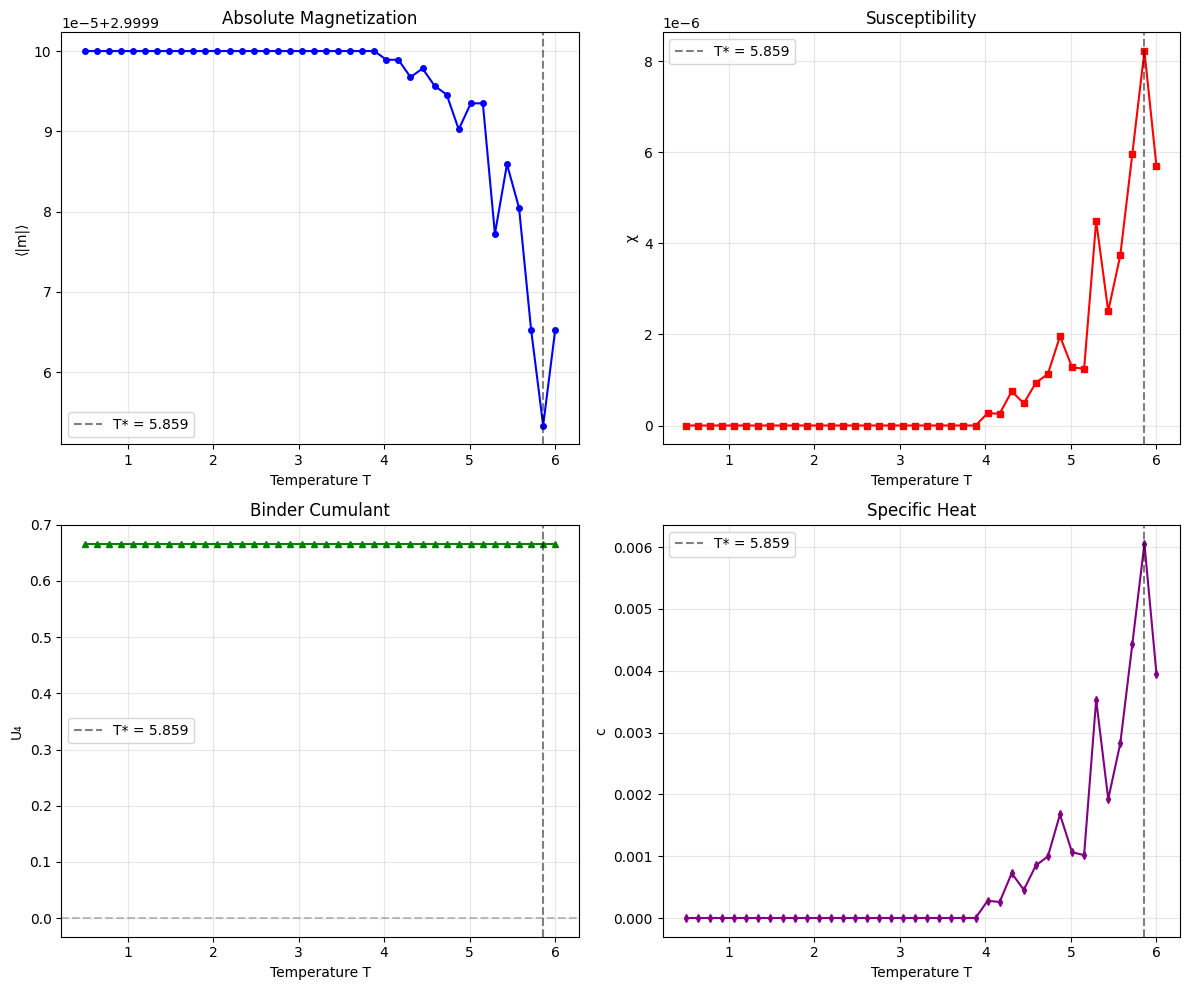


Total simulation time: 421.8 seconds
Running simulation with L=16, J=1.0, α=1.0, λ=5.0, Rc=5.0
Temperature range: [1.0, 4.0] with 10 points
Equilibration: 50 sweeps, Measurement: 100 sweeps
RNG seed: 123

Temperature 1/10: T = 4.000
Temperature 2/10: T = 3.667
Temperature 3/10: T = 3.333
Temperature 4/10: T = 3.000
Temperature 5/10: T = 2.667
Temperature 6/10: T = 2.333
Temperature 7/10: T = 2.000
Temperature 8/10: T = 1.667
Temperature 9/10: T = 1.333
Temperature 10/10: T = 1.000

Estimated transition temperature: T* = 3.333
Peak susceptibility: χ_max = 0.01


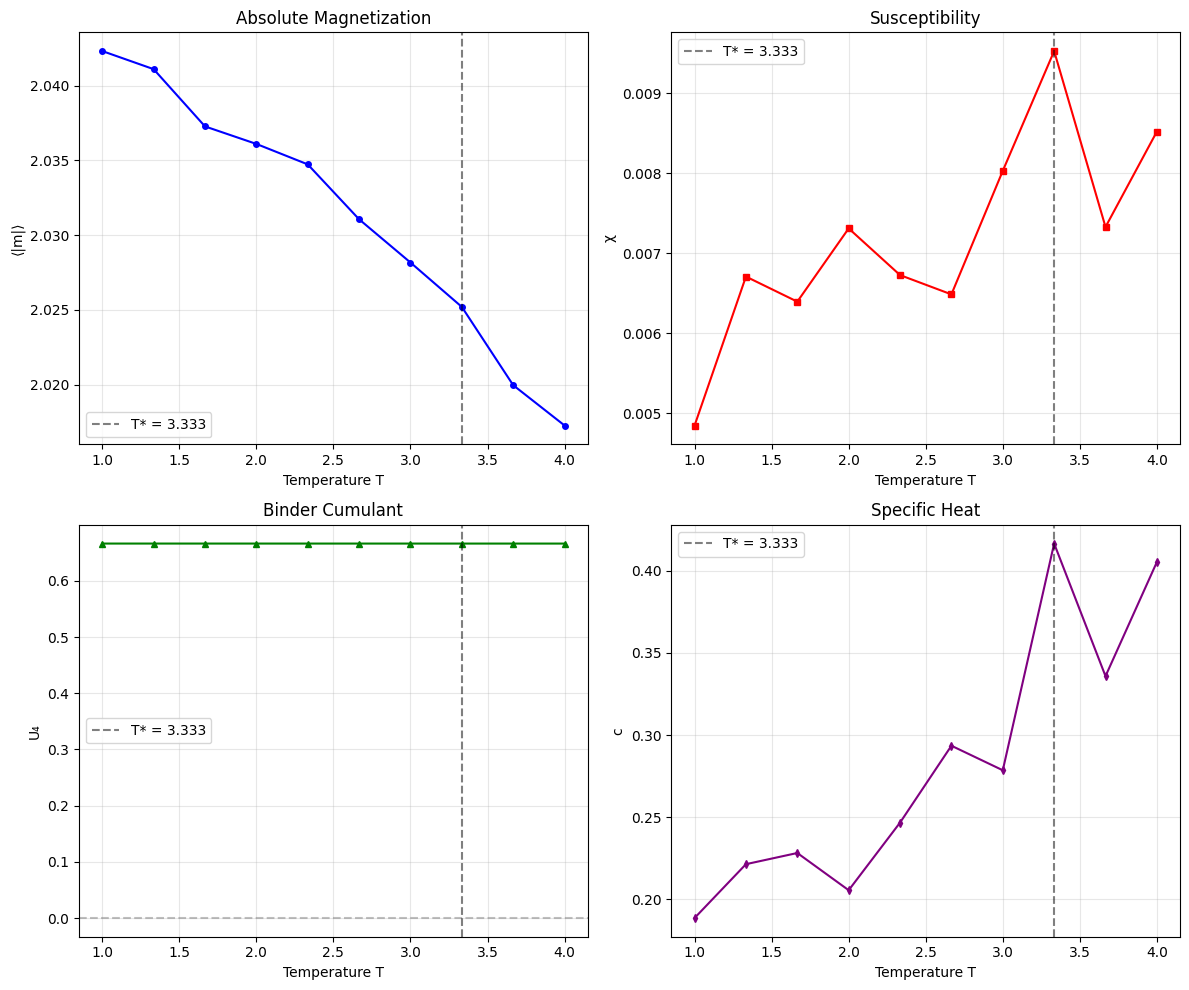

Test Case 1 Completed
Running simulation with L=16, J=1.0, α=1.0, λ=5.0, Rc=5.0
Temperature range: [1.0, 4.0] with 10 points
Equilibration: 50 sweeps, Measurement: 100 sweeps
RNG seed: 456

Temperature 1/10: T = 4.000
Temperature 2/10: T = 3.667
Temperature 3/10: T = 3.333
Temperature 4/10: T = 3.000
Temperature 5/10: T = 2.667
Temperature 6/10: T = 2.333
Temperature 7/10: T = 2.000
Temperature 8/10: T = 1.667
Temperature 9/10: T = 1.333
Temperature 10/10: T = 1.000

Estimated transition temperature: T* = 3.333
Peak susceptibility: χ_max = 0.01


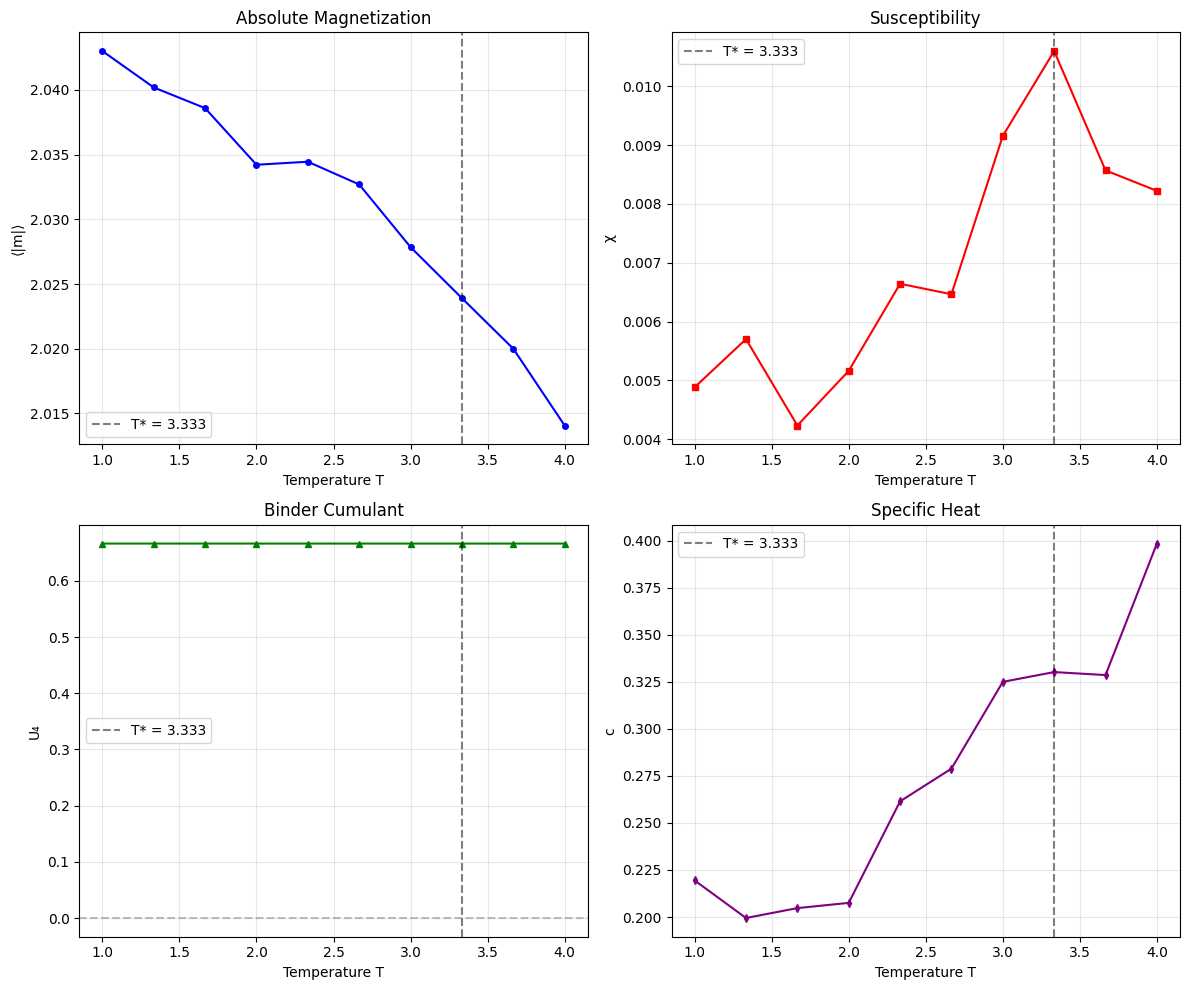

Test Case 2 Completed
Running simulation with L=1, J=1.0, α=1.0, λ=1.0, Rc=1.0
Temperature range: [0.5, 1.0] with 5 points
Equilibration: 10 sweeps, Measurement: 20 sweeps
RNG seed: 789

Temperature 1/5: T = 1.000
Temperature 2/5: T = 0.875
Temperature 3/5: T = 0.750
Temperature 4/5: T = 0.625
Temperature 5/5: T = 0.500

Estimated transition temperature: T* = 0.500
Peak susceptibility: χ_max = 1.10


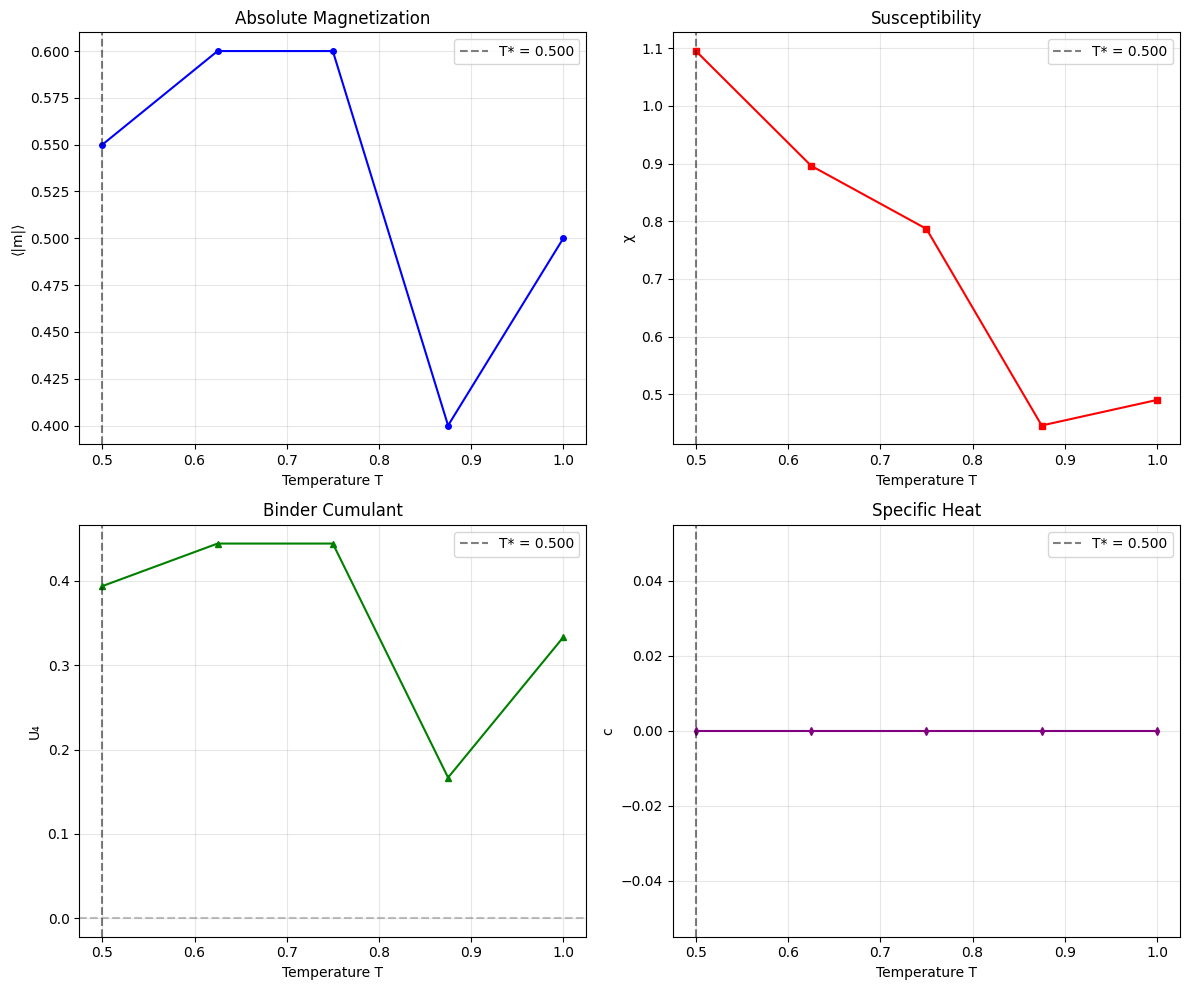

Test Case 3 Completed
Running simulation with L=16, J=1.0, α=1.0, λ=5.0, Rc=5.0
Temperature range: [0.1, 100.0] with 10 points
Equilibration: 50 sweeps, Measurement: 100 sweeps
RNG seed: 101

Temperature 1/10: T = 100.000
Temperature 2/10: T = 88.900
Temperature 3/10: T = 77.800
Temperature 4/10: T = 66.700
Temperature 5/10: T = 55.600
Temperature 6/10: T = 44.500
Temperature 7/10: T = 33.400
Temperature 8/10: T = 22.300
Temperature 9/10: T = 11.200
Temperature 10/10: T = 0.100

Estimated transition temperature: T* = 33.400
Peak susceptibility: χ_max = 0.25


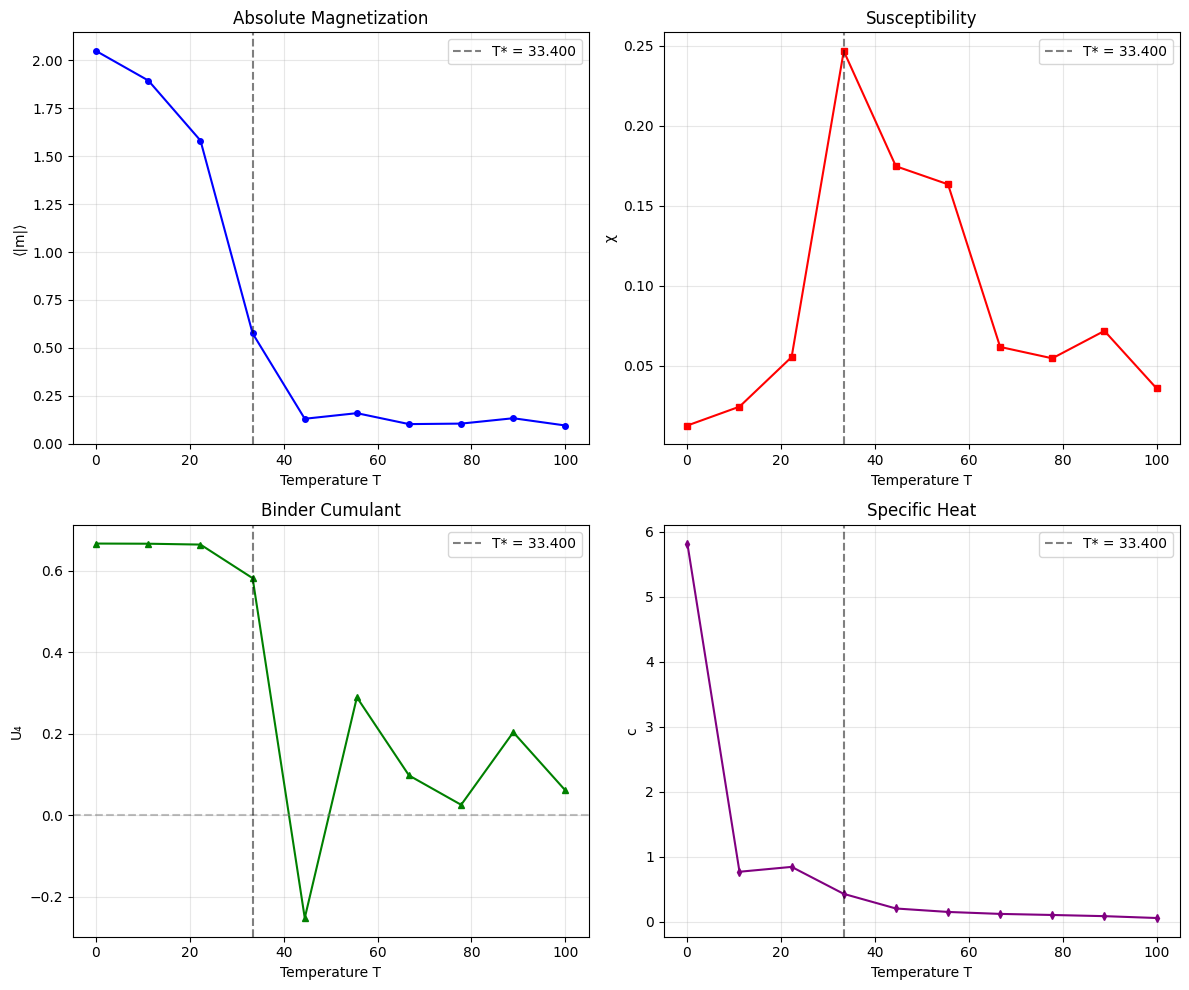

Test Case 4 Completed


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from typing import Tuple, Dict
import time

class LatticeModel:
    """
    7-level lattice model with quartic on-site potential and 
    exponentially decaying interactions.
    """
    
    def __init__(self, L: int, J: float = 1.0, alpha: float = 1.0, 
                 lambda_decay: float = 10.0, R_c: float = 10.0, seed: int = 42):
        """
        Initialize the lattice model.
        
        Parameters:
        - L: Linear system size (L x L lattice)
        - J: Interaction strength
        - alpha: Quartic potential strength
        - lambda_decay: Decay length for interactions
        - R_c: Cutoff radius for interactions
        - seed: Random number generator seed
        """
        self.L = L
        self.N = L * L
        self.J = J
        self.alpha = alpha
        self.lambda_decay = lambda_decay
        self.R_c = R_c
        self.states = np.array([-3, -2, -1, 0, 1, 2, 3])
        
        # Initialize RNG
        self.rng = np.random.RandomState(seed)
        
        # Initialize configuration randomly
        self.x = self.rng.choice(self.states, size=(L, L))
        
        # Precompute interaction kernel for FFT-based convolution
        self.kernel = self._compute_kernel()
        
        # Precompute on-site potentials
        self.V = alpha * (self.states**4 - self.states**2)
        
    def _compute_kernel(self) -> np.ndarray:
        """
        Compute the interaction kernel w(r) = exp(-r/λ) with periodic boundaries.
        Returns kernel suitable for FFT-based circular convolution.
        """
        kernel = np.zeros((self.L, self.L))
        
        for dx in range(self.L):
            for dy in range(self.L):
                # Minimum image convention
                dx_min = min(dx, self.L - dx)
                dy_min = min(dy, self.L - dy)
                
                if dx_min == 0 and dy_min == 0:
                    # No self-interaction
                    kernel[dx, dy] = 0
                else:
                    r = np.sqrt(dx_min**2 + dy_min**2)
                    if r <= self.R_c:
                        kernel[dx, dy] = np.exp(-r / self.lambda_decay)
                    else:
                        kernel[dx, dy] = 0
        
        return kernel
    
    def compute_local_fields(self) -> np.ndarray:
        """
        Compute local fields h_i = J * sum_j w(r_ij) * x_j using FFT convolution.
        """
        # Use circular convolution via FFT for efficiency
        h = self.J * signal.fftconvolve(self.x, self.kernel, mode='same', axes=(0, 1))
        return h
    
    def parallel_heat_bath_update(self, beta: float):
        """
        Perform one parallel heat-bath sweep.
        Each site is independently resampled from its conditional distribution.
        """
        # Compute local fields
        h = self.compute_local_fields()
        
        # For each site, compute conditional probabilities
        # E_i(u) = V(u) - h_i * u
        # P(x_i = u) ∝ exp(-β * E_i(u))
        
        # Vectorized computation of probabilities for all sites and states
        # Shape: (L, L, 7)
        energies = self.V[np.newaxis, np.newaxis, :] - h[:, :, np.newaxis] * self.states[np.newaxis, np.newaxis, :]
        
        # Compute probabilities with numerical stability
        prob = np.exp(-beta * (energies - energies.min(axis=2, keepdims=True)))
        prob = prob / prob.sum(axis=2, keepdims=True)
        
        # Sample new configuration
        new_x = np.zeros_like(self.x)
        for i in range(self.L):
            for j in range(self.L):
                new_x[i, j] = self.rng.choice(self.states, p=prob[i, j])
        
        self.x = new_x
    
    def compute_energy(self) -> float:
        """
        Compute total energy of current configuration.
        """
        # On-site potential
        V_total = np.sum(self.alpha * (self.x**4 - self.x**2))
        
        # Interaction energy (factor of 0.5 to avoid double counting)
        h = self.compute_local_fields()
        interaction_energy = -0.5 * np.sum(self.x * h)
        
        return V_total + interaction_energy
    
    def compute_magnetization(self) -> float:
        """
        Compute intensive magnetization m = (1/N) * sum_i x_i
        """
        return np.mean(self.x)
    
    def measure_observables(self) -> Dict[str, float]:
        """
        Measure all observables for current configuration.
        """
        m = self.compute_magnetization()
        E = self.compute_energy()
        
        return {
            'magnetization': m,
            'abs_magnetization': np.abs(m),
            'magnetization_squared': m**2,
            'magnetization_fourth': m**4,
            'energy': E,
            'energy_squared': E**2
        }


def run_simulation(L: int = 48, J: float = 1.0, alpha: float = 1.0,
                  lambda_decay: float = 10.0, R_c: float = 10.0,
                  T_min: float = 0.5, T_max: float = 6.0, n_temps: int = 40,
                  n_eq: int = 200, n_meas: int = 400, seed: int = 42) -> Dict:
    """
    Run Monte Carlo simulation across temperature range to detect phase transition.
    """
    print(f"Running simulation with L={L}, J={J}, α={alpha}, λ={lambda_decay}, Rc={R_c}")
    print(f"Temperature range: [{T_min}, {T_max}] with {n_temps} points")
    print(f"Equilibration: {n_eq} sweeps, Measurement: {n_meas} sweeps")
    print(f"RNG seed: {seed}\n")
    
    # Temperature grid
    temperatures = np.linspace(T_max, T_min, n_temps)
    
    # Storage for results
    results = {
        'T': temperatures,
        'abs_m': np.zeros(n_temps),
        'chi': np.zeros(n_temps),
        'U4': np.zeros(n_temps),
        'c': np.zeros(n_temps),
        'abs_m_err': np.zeros(n_temps),
        'chi_err': np.zeros(n_temps),
        'U4_err': np.zeros(n_temps),
        'c_err': np.zeros(n_temps)
    }
    
    # Initialize model
    model = LatticeModel(L, J, alpha, lambda_decay, R_c, seed)
    
    for idx, T in enumerate(temperatures):
        beta = 1.0 / T
        print(f"Temperature {idx+1}/{n_temps}: T = {T:.3f}")
        
        # Equilibration
        for _ in range(n_eq):
            model.parallel_heat_bath_update(beta)
        
        # Measurements
        measurements = {
            'abs_m': [],
            'm': [],
            'm2': [],
            'm4': [],
            'E': [],
            'E2': []
        }
        
        for _ in range(n_meas):
            model.parallel_heat_bath_update(beta)
            obs = model.measure_observables()
            
            measurements['abs_m'].append(obs['abs_magnetization'])
            measurements['m'].append(obs['magnetization'])
            measurements['m2'].append(obs['magnetization_squared'])
            measurements['m4'].append(obs['magnetization_fourth'])
            measurements['E'].append(obs['energy'])
            measurements['E2'].append(obs['energy_squared'])
        
        # Compute averages and derived quantities
        abs_m_mean = np.mean(measurements['abs_m'])
        m_mean = np.mean(measurements['m'])
        m2_mean = np.mean(measurements['m2'])
        m4_mean = np.mean(measurements['m4'])
        E_mean = np.mean(measurements['E'])
        E2_mean = np.mean(measurements['E2'])
        
        # Susceptibility: χ = β * N * (<m²> - <m>²)
        chi = beta * model.N * (m2_mean - m_mean**2)
        
        # Binder cumulant: U4 = 1 - <m⁴>/(3<m²>²)
        if m2_mean > 1e-10:
            U4 = 1 - m4_mean / (3 * m2_mean**2)
        else:
            U4 = 0
        
        # Specific heat: c = β²/N * (<H²> - <H>²)
        c = beta**2 / model.N * (E2_mean - E_mean**2)
        
        # Store results
        results['abs_m'][idx] = abs_m_mean
        results['chi'][idx] = chi
        results['U4'][idx] = U4
        results['c'][idx] = c
        
        # Estimate errors using block averaging (simplified)
        block_size = max(1, n_meas // 10)
        n_blocks = n_meas // block_size
        
        if n_blocks > 1:
            abs_m_blocks = [np.mean(measurements['abs_m'][i*block_size:(i+1)*block_size]) 
                           for i in range(n_blocks)]
            results['abs_m_err'][idx] = np.std(abs_m_blocks) / np.sqrt(n_blocks - 1)
    
    # Find transition temperature from peak in susceptibility
    T_star_idx = np.argmax(results['chi'])
    T_star = results['T'][T_star_idx]
    
    print(f"\nEstimated transition temperature: T* = {T_star:.3f}")
    print(f"Peak susceptibility: χ_max = {results['chi'][T_star_idx]:.2f}")
    
    return results


def plot_results(results: Dict):
    """
    Plot the thermodynamic observables vs temperature.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Absolute magnetization
    axes[0, 0].plot(results['T'], results['abs_m'], 'o-', color='blue', markersize=4)
    axes[0, 0].set_xlabel('Temperature T')
    axes[0, 0].set_ylabel('⟨|m|⟩')
    axes[0, 0].set_title('Absolute Magnetization')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Susceptibility
    axes[0, 1].plot(results['T'], results['chi'], 's-', color='red', markersize=4)
    axes[0, 1].set_xlabel('Temperature T')
    axes[0, 1].set_ylabel('χ')
    axes[0, 1].set_title('Susceptibility')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Binder cumulant
    axes[1, 0].plot(results['T'], results['U4'], '^-', color='green', markersize=4)
    axes[1, 0].set_xlabel('Temperature T')
    axes[1, 0].set_ylabel('U₄')
    axes[1, 0].set_title('Binder Cumulant')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    # Specific heat
    axes[1, 1].plot(results['T'], results['c'], 'd-', color='purple', markersize=4)
    axes[1, 1].set_xlabel('Temperature T')
    axes[1, 1].set_ylabel('c')
    axes[1, 1].set_title('Specific Heat')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Mark transition temperature
    T_star_idx = np.argmax(results['chi'])
    T_star = results['T'][T_star_idx]
    for ax in axes.flat:
        ax.axvline(x=T_star, color='black', linestyle='--', alpha=0.5, 
                  label=f'T* = {T_star:.3f}')
        ax.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    
    return fig


# Run the simulation
if __name__ == "__main__":
    start_time = time.time()
    
    # Run with recommended defaults
    results = run_simulation(
        L=48,           # System size (use 48 or 64)
        J=1.0,          # Interaction strength
        alpha=1.0,      # Quartic potential strength
        lambda_decay=10.0,  # Decay length
        R_c=10.0,       # Cutoff radius
        T_min=0.5,      # Minimum temperature
        T_max=6.0,      # Maximum temperature
        n_temps=40,     # Number of temperature points
        n_eq=200,       # Equilibration sweeps
        n_meas=400,     # Measurement sweeps
        seed=42         # RNG seed for reproducibility
    )
    
    # Plot results
    fig = plot_results(results)
    
    elapsed_time = time.time() - start_time
    print(f"\nTotal simulation time: {elapsed_time:.1f} seconds")
# Test Case 1: Happy Path
# Run the simulation with a smaller lattice size and fewer temperature points to ensure it completes quickly.
results_test1 = run_simulation(L=16, J=1.0, alpha=1.0, lambda_decay=5.0, R_c=5.0, T_min=1.0, T_max=4.0, n_temps=10, n_eq=50, n_meas=100, seed=123)
fig_test1 = plot_results(results_test1)
print("Test Case 1 Completed")
# Expected output: A plot of thermodynamic observables with a clear peak in susceptibility.
# Test Case 2: Happy Path
# Run the simulation with a different seed to check for reproducibility.
results_test2 = run_simulation(L=16, J=1.0, alpha=1.0, lambda_decay=5.0, R_c=5.0, T_min=1.0, T_max=4.0, n_temps=10, n_eq=50, n_meas=100, seed=456)
fig_test2 = plot_results(results_test2)
print("Test Case 2 Completed")
# Expected output: A plot of thermodynamic observables with a clear peak in susceptibility, different from Test Case 1 due to different seed.
# Test Case 3: Edge Case
# Run the simulation with the smallest possible lattice size (L=1) to test edge behavior.
results_test3 = run_simulation(L=1, J=1.0, alpha=1.0, lambda_decay=1.0, R_c=1.0, T_min=0.5, T_max=1.0, n_temps=5, n_eq=10, n_meas=20, seed=789)
fig_test3 = plot_results(results_test3)
print("Test Case 3 Completed")
# Expected output: A plot with limited data points, potentially no clear peak in susceptibility due to small system size.
# Test Case 4: Edge Case
# Run the simulation with a very high temperature range to test stability.
results_test4 = run_simulation(L=16, J=1.0, alpha=1.0, lambda_decay=5.0, R_c=5.0, T_min=0.1, T_max=100.0, n_temps=10, n_eq=50, n_meas=100, seed=101)
fig_test4 = plot_results(results_test4)
print("Test Case 4 Completed")
# Expected output: A plot showing behavior over a wide temperature range, possibly with unusual susceptibility behavior at high temperatures.

In [8]:

import numpy as np
import math
from typing import Tuple, List

# ----------------------------
# Utilities: perfect matchings
# ----------------------------

def random_matching(num_points: int, rng: np.random.Generator) -> np.ndarray:
    """Sample a uniform random perfect matching on {0,...,num_points-1}.
    Returns an array m with m[i]=j, m[j]=i, i!=j.
    """
    assert num_points % 2 == 0
    perm = rng.permutation(num_points)
    m = np.empty(num_points, dtype=np.int32)
    for a, b in perm.reshape(-1, 2):
        m[a] = b
        m[b] = a
    return m

# ----------------------------
# Model statistics
# ----------------------------

def chords_from_matching(m: np.ndarray) -> List[Tuple[int, int]]:
    """Return list of chords (i,j) with i<j from matching array m."""
    chords = []
    seen = np.zeros(len(m), dtype=bool)
    for i in range(len(m)):
        if not seen[i]:
            j = int(m[i])
            seen[i] = True
            seen[j] = True
            if i < j:
                chords.append((i, j))
            else:
                chords.append((j, i))
    return chords

def crossing_count(m: np.ndarray) -> int:
    """Count chord crossings among chords of matching m.
    Complexity: O(N^2) with N=number of chords.
    """
    chords = chords_from_matching(m)
    X = 0
    for idx in range(len(chords)):
        i, j = chords[idx]
        for kdx in range(idx + 1, len(chords)):
            k, l = chords[kdx]
            # crossing iff i<k<j<l or k<i<l<j
            if (i < k < j < l) or (k < i < l < j):
                X += 1
    return X

def cycles_and_small_loops(m: np.ndarray, r: np.ndarray, L_star: int) -> Tuple[int, int]:
    """Return (c, N_le) where c is number of alternating cycles in union of m and r,
    and N_le counts cycles whose number of m-edges <= L_star.
    Traverses cycles by alternating m-edge then r-edge.
    Complexity: O(num_points).
    """
    n = len(m)
    visited = np.zeros(n, dtype=bool)
    c = 0
    n_small = 0
    for start in range(n):
        if visited[start]:
            continue
        # trace one cycle
        cur = start
        length_m_edges = 0
        while True:
            visited[cur] = True
            nxt = int(m[cur])  # m-edge
            length_m_edges += 1
            visited[nxt] = True
            cur = int(r[nxt])  # r-edge
            if cur == start:
                break
        c += 1
        if length_m_edges <= L_star:
            n_small += 1
    return c, n_small

# ----------------------------
# Proposals (2-switch) and MH step
# ----------------------------

def two_switch_proposal(m: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Pick two disjoint chords (a,b) and (c,d) and rewire to either (a,c),(b,d) or (a,d),(b,c).
    Returns new matching array.
    """
    chords = chords_from_matching(m)
    N = len(chords)
    i, j = rng.integers(0, N, size=2, endpoint=False)
    while j == i:
        j = rng.integers(0, N, endpoint=False)
    (a, b) = chords[i]
    (c, d) = chords[j]
    m2 = m.copy()
    # disconnect old (mark temps)
    m2[a] = a
    m2[b] = b
    m2[c] = c
    m2[d] = d
    if rng.random() < 0.5:
        # (a,c),(b,d)
        m2[a] = c; m2[c] = a
        m2[b] = d; m2[d] = b
    else:
        # (a,d),(b,c)
        m2[a] = d; m2[d] = a
        m2[b] = c; m2[c] = b
    return m2

def mh_step(m: np.ndarray, r: np.ndarray, L_star: int, lam: float, alpha: float,
            rng: np.random.Generator,
            cached_stats: Tuple[int,int,int] = None) -> Tuple[np.ndarray, Tuple[int,int,int]]:
    """One Metropolis–Hastings step at fixed (lam, alpha).
    cached_stats = (X, c, n_small) for current m may be provided to save recomputation.
    Returns (m_next, stats_next).
    """
    if cached_stats is None:
        X = crossing_count(m)
        c, n_small = cycles_and_small_loops(m, r, L_star)
    else:
        X, c, n_small = cached_stats

    m_prop = two_switch_proposal(m, rng)
    Xp = crossing_count(m_prop)
    cp, nsp = cycles_and_small_loops(m_prop, r, L_star)

    dX = Xp - X
    dc = cp - c
    dn = nsp - n_small

    log_ratio = -(lam * dX + alpha * dn) - (dc * math.log(2.0))
    if log_ratio >= 0 or math.log(rng.random()) < log_ratio:
        return m_prop, (Xp, cp, nsp)
    else:
        return m, (X, c, n_small)

# ----------------------------
# Thermodynamic integration
# ----------------------------

def base_logZ_N(N: int) -> float:
    """log Z_N(0,0) = 3 N log 2 + lgamma(N+1/4) - lgamma(1/4)."""
    return 3 * N * math.log(2.0) + math.lgamma(N + 0.25) - math.lgamma(0.25)

def mcmc_expectations(N: int, lam: float, alpha: float, L_star: int, sweeps: int,
                      rng: np.random.Generator,
                      m_init: np.ndarray = None,
                      r: np.ndarray = None,
                      burn_sweeps: int = None) -> Tuple[float, float, float, np.ndarray, np.ndarray]:
    """Run MCMC at fixed (lam, alpha). Returns (E[X], E[N_le], E[c], m_last, r).
    One sweep = 2N proposals. If m_init is None, initialize randomly. If r is None, sample rods once.
    """
    if r is None:
        r = random_matching(2 * N, rng)
    if m_init is None:
        m = random_matching(2 * N, rng)
    else:
        m = m_init.copy()

    if burn_sweeps is None:
        burn_sweeps = max(5, sweeps // 10)

    X = crossing_count(m)
    c, n_small = cycles_and_small_loops(m, r, L_star)

    def do_sweep(m, stats):
        X, c, n_small = stats
        for _ in range(2 * N):
            m, (X, c, n_small) = mh_step(m, r, L_star, lam, alpha, rng, (X, c, n_small))
        return m, (X, c, n_small)

    # burn-in
    for _ in range(burn_sweeps):
        m, (X, c, n_small) = do_sweep(m, (X, c, n_small))

    # collect
    sum_X = 0.0
    sum_n = 0.0
    sum_c = 0.0
    samples = 0
    for _ in range(sweeps):
        m, (X, c, n_small) = do_sweep(m, (X, c, n_small))
        sum_X += X
        sum_n += n_small
        sum_c += c
        samples += 1
    return (sum_X / samples, sum_n / samples, sum_c / samples, m, r)

def trapezoid(xs: np.ndarray, ys: np.ndarray) -> float:
    return float(np.trapz(ys, xs))

def thermo_integrate(N: int, L_star: int, lam_grid: np.ndarray, alpha_grid: np.ndarray,
                     sweeps: int, rng: np.random.Generator):
    """Follow path (0,0)->(lam_max,0)->(lam_max,alpha_max) and return
    logZ(lam_max, alpha_max) and a dict of diagnostics with grids and expectations.
    """
    # Fixed rod structure sampled once
    r = random_matching(2 * N, rng)

    # Stage 1: alpha=0, vary lambda
    EX = []
    m = None
    for lam in lam_grid:
        ex, en, ec, m, _ = mcmc_expectations(N, lam, 0.0, L_star, sweeps, rng, m_init=m, r=r)
        EX.append(ex)
    EX = np.array(EX)
    I_lambda = trapezoid(lam_grid, EX)  # integral of E[X] d lambda

    # Stage 2: lambda = lam_max, vary alpha
    lam_max = float(lam_grid[-1])
    EN = []
    for alpha in alpha_grid:
        ex, en, ec, m, _ = mcmc_expectations(N, lam_max, alpha, L_star, sweeps, rng, m_init=m, r=r)
        EN.append(en)
    EN = np.array(EN)
    I_alpha = trapezoid(alpha_grid, EN)  # integral of E[N_le] d alpha

    logZ00 = base_logZ_N(N)
    logZ = logZ00 - I_lambda - I_alpha

    diag = {
        "lam_grid": lam_grid, "EX": EX,
        "alpha_grid": alpha_grid, "EN": EN,
        "I_lambda": I_lambda, "I_alpha": I_alpha,
        "logZ00": logZ00,
    }
    return logZ, diag

if __name__ == "__main__":
    rng = np.random.default_rng(123)
    N = 200
    L_star = 6
    lam_grid = np.linspace(0.0, 1.0, 4)
    alpha_grid = np.linspace(0.0, 0.5, 3)
    sweeps = 20
    logZ, diag = thermo_integrate(N, L_star, lam_grid, alpha_grid, sweeps, rng)
    print(f"log Z_N(lam={lam_grid[-1]:.3f}, alpha={alpha_grid[-1]:.3f}) ≈ {logZ:.4f}")
    print("I_lambda=", diag["I_lambda"], "I_alpha=", diag["I_alpha"], "logZ00=", diag["logZ00"])


log Z_N(lam=1.000, alpha=0.500) ≈ -145.6628
I_lambda= 1419.3333333333333 I_alpha= 0.1875 logZ00= 1273.858066033818


In [18]:
import numpy as np

# ---------------------------
# Model + simulation settings
# ---------------------------
L = 64                       # lattice size (PBC)
J = 0.05                     # interaction strength
alpha = 1.0                  # on-site potential scale in V(u)=alpha*(u**4 - u**2)
lam = 2.0                    # decay length in w(r)=exp(-r/lam)
R_c = 10.0                   # cutoff radius for kernel (<= lam to keep it local+fast)
temps = np.linspace(10.0, 0.01, 100)   # temperature grid (high -> low)
N_eq = 200                   # equilibration sweeps per T
N_meas = 400                 # measurement sweeps per T
seeds = [123456, 789011, 424242]      # three RNG seeds

# Discrete 7-level set and on-site potential
STATES = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=np.float64)
V_STATES = alpha * (STATES**4 - STATES**2)             # shape (7,)

# ---------------------------
# Build periodic kernel w(x,y)
# ---------------------------
def build_kernel(L, lam=10.0, R_c=10.0):
    # periodic minimum-image distances
    dx = np.minimum(np.arange(L), L - np.arange(L))
    dy = dx.copy()
    X, Y = np.meshgrid(dx, dy, indexing='xy')
    R = np.hypot(X, Y).astype(np.float64)
    W = np.exp(-R / lam)
    W[R == 0] = 0.0  # no self-interaction
    if R_c is not None and R_c > 0:
        W = np.where(R <= R_c, W, 0.0)
    return W

W = build_kernel(L, lam=lam, R_c=R_c)
W_fft = np.fft.fft2(W)  # precompute FFT of kernel
N_sites = L * L

# -------------
# Observables helpers
# -------------
def energy_total(x, h):
    """
    Total energy H(x) = sum_i V(x_i) - 0.5 * sum_i x_i * (J*sum_j w_ij x_j)
                      = sum_i V(x_i) - 0.5 * sum_i x_i * h_i
    where h is the field computed with the current x (w(0)=0).
    """
    Vsum = (alpha * (x**4 - x**2)).sum()
    pair = -0.5 * np.sum(x * h)
    return Vsum + pair  # scalar (total energy)

def binder_u4_from_moments(m2, m4):
    return 1.0 - (m4 / (3.0 * (m2**2) + 1e-300))

# -------------
# Heat-bath step (parallel / synchronous)
# -------------
def heat_bath_parallel(x, beta, J, W_fft, rng):
    """
    Perform one parallel heat-bath sweep using FFT-accelerated field.
    x: (L,L) current field
    Returns: (x_new, h_new) after the sweep.
    """
    # compute local field h = J * (w * x) via circular convolution
    h = J * np.fft.ifft2(np.fft.fft2(x) * W_fft).real   # (L,L)

    # sitewise categorical sampling over the 7 levels
    # logits(u) = -beta * [ V(u) - h * u ]
    logits = -beta * (V_STATES[:, None, None] - h[None, :, :] * STATES[:, None, None])
    # numerical stability
    logits -= logits.max(axis=0, keepdims=True)
    probs = np.exp(logits)
    probs_sum = probs.sum(axis=0, keepdims=True)
    probs /= probs_sum

    # sample category per site using inverse-CDF
    cdf = np.cumsum(probs, axis=0)  # shape (7,L,L), last slice should be ~1
    U = rng.random(size=x.shape)
    # Guard against rare numerical drift
    U = np.minimum(U, 1.0 - 1e-12)
    k = np.argmax(cdf >= U[None, :, :], axis=0)
    x_new = STATES[k]

    # field for the new configuration (needed for energy and next step)
    h_new = J * np.fft.ifft2(np.fft.fft2(x_new) * W_fft).real
    return x_new, h_new

# ---------------------------
# Jackknife utilities
# ---------------------------
def jackknife_stats_m_series(m, beta):
    """
    Given m time series (length n), return:
      - m_abs_mean and its jackknife stderr
      - chi and its jackknife stderr
      - U4 and its jackknife stderr
    """
    m = np.asarray(m)
    n = m.size
    abs_m = np.abs(m)

    # Precompute moments
    S1 = m.sum()
    S2 = (m*m).sum()
    S4 = (m**4).sum()
    Sabs = abs_m.sum()

    # Point estimates
    mean_m   = S1 / n
    mean_m2  = S2 / n
    mean_m4  = S4 / n
    m_abs_mean = Sabs / n

    chi = beta * N_sites * (mean_m2 - mean_m**2)
    U4 = binder_u4_from_moments(mean_m2, mean_m4)

    # Jackknife leave-one-out means (vectorized)
    n1 = n - 1.0
    mean_m_lo   = (S1 - m)   / n1
    mean_m2_lo  = (S2 - m*m) / n1
    mean_m4_lo  = (S4 - m**4)/ n1
    mean_abs_lo = (Sabs - abs_m) / n1

    chi_lo = beta * N_sites * (mean_m2_lo - mean_m_lo**2)
    U4_lo  = 1.0 - (mean_m4_lo / (3.0 * (mean_m2_lo**2) + 1e-300))
    mabs_lo = mean_abs_lo

    # Jackknife variance: (n-1)/n * sum (theta_lo - mean(theta_lo))^2
    def jk_stderr(theta_lo):
        tbar = theta_lo.mean()
        var = (n - 1.0) / n * np.mean((theta_lo - tbar)**2)
        return np.sqrt(var)

    m_abs_se = jk_stderr(mabs_lo)
    chi_se   = jk_stderr(chi_lo)
    U4_se    = jk_stderr(U4_lo)

    return (m_abs_mean, m_abs_se), (chi, chi_se), (U4, U4_se)

def jackknife_stats_energy_series(H, beta):
    """
    Given total energy H time series (length n), return:
      - C (specific heat per spin) and jackknife stderr
      - E_per_spin mean and jackknife stderr
    Using:
      C = beta^2 / N * ( <H^2> - <H>^2 )
      e = <H>/N
    """
    H = np.asarray(H)
    n = H.size
    S1 = H.sum()
    S2 = (H*H).sum()

    mean_H  = S1 / n
    mean_H2 = S2 / n

    C = (beta**2 / N_sites) * (mean_H2 - mean_H**2)
    e_mean = mean_H / N_sites

    n1 = n - 1.0
    mean_H_lo  = (S1 - H) / n1
    mean_H2_lo = (S2 - H*H) / n1

    C_lo = (beta**2 / N_sites) * (mean_H2_lo - mean_H_lo**2)
    e_lo = mean_H_lo / N_sites

    def jk_stderr(theta_lo):
        tbar = theta_lo.mean()
        var = (n - 1.0) / n * np.mean((theta_lo - tbar)**2)
        return np.sqrt(var)

    C_se = jk_stderr(C_lo)
    e_se = jk_stderr(e_lo)

    return (C, C_se), (e_mean, e_se)

# ---------------------------
# Single-seed run
# ---------------------------
def run_single_seed(seed):
    rng = np.random.default_rng(seed)
    x = rng.choice(STATES, size=(L, L))  # random initial configuration

    per_T = []  # list of dicts, one per temperature

    for T in temps:
        beta = 1.0 / T

        # Equilibration
        for _ in range(N_eq):
            x, h = heat_bath_parallel(x, beta, J, W_fft, rng)

        # Measurements (store time series for jackknife)
        m_series = np.empty(N_meas, dtype=np.float64)
        H_series = np.empty(N_meas, dtype=np.float64)

        for t in range(N_meas):
            x, h = heat_bath_parallel(x, beta, J, W_fft, rng)
            m_series[t] = x.mean()
            H_series[t] = energy_total(x, h)  # total energy

        # Within-seed estimates + jackknife SEs
        (mabs_mean, mabs_se), (chi, chi_se), (U4, U4_se) = jackknife_stats_m_series(m_series, beta)
        (C, C_se), (e_mean, e_se) = jackknife_stats_energy_series(H_series, beta)

        per_T.append({
            "T": float(T),
            "m_abs": (float(mabs_mean), float(mabs_se)),
            "chi":   (float(chi), float(chi_se)),
            "U4":    (float(U4), float(U4_se)),
            "C":     (float(C), float(C_se)),
            "E_per_spin": (float(e_mean), float(e_se)),
            "seed": seed
        })

    return per_T

# ---------------------------
# Aggregate across seeds
# ---------------------------
def combine_seeds(seed_results):
    """
    seed_results: list of lists (len = n_seeds) where each inner list has per-T dicts.
    Returns list of per-T dicts with combined mean and a single combined error:
       err_total = sqrt( (mean within-seed SE)^2 + (SE of seed means)^2 )
    """
    n_seeds = len(seed_results)
    n_T = len(seed_results[0])
    out = []

    for t_idx in range(n_T):
        T = seed_results[0][t_idx]["T"]

        row = {"T": T}
        for key in ["m_abs", "chi", "U4", "C", "E_per_spin"]:
            means = np.array([seed_results[s][t_idx][key][0] for s in range(n_seeds)], dtype=np.float64)
            ses   = np.array([seed_results[s][t_idx][key][1] for s in range(n_seeds)], dtype=np.float64)

            mean_val = means.mean()
            mean_internal_se = ses.mean()
            # standard error of the seed means (between-seed)
            if n_seeds > 1:
                se_across = means.std(ddof=1) / np.sqrt(n_seeds)
            else:
                se_across = 0.0

            # single reported error: quadrature combination
            err_total = float(np.sqrt(mean_internal_se**2 + se_across**2))

            row[key] = (float(mean_val), err_total)

        out.append(row)

    return out

# ---------------------------
# Report helpers
# ---------------------------
def estimate_Tc_from_chi(combined):
    chis = np.array([c["chi"][0] for c in combined])
    Ts   = np.array([c["T"] for c in combined])
    idx = int(np.argmax(chis))
    return float(Ts[idx])

def print_table(combined, seeds_used):
    print(f"Seeds: {seeds_used}")
    Tc_est = estimate_Tc_from_chi(combined)
    print(f"Estimated transition temperature (from combined susceptibility peak): T* ≈ {Tc_est:.4f}")
    print("T,  <|m|>±err,  chi±err,  U4±err,  C±err,  E/N±err")
    for r in combined:
        T = r["T"]
        m_abs, m_abs_e = r["m_abs"]
        chi, chi_e = r["chi"]
        U4, U4_e = r["U4"]
        C, C_e = r["C"]
        e, e_e = r["E_per_spin"]
        print(f"{T:7.3f}, {m_abs:.6f}±{m_abs_e:.6f}, {chi:.6f}±{chi_e:.6f}, "
              f"{U4:.6f}±{U4_e:.6f}, {C:.6f}±{C_e:.6f}, {e:.6f}±{e_e:.6f}")

# ---------------------------
# Main
# ---------------------------
if __name__ == "__main__":
    # Run all seeds
    all_seed_results = []
    for sd in seeds:
        res = run_single_seed(sd)
        all_seed_results.append(res)

    # Combine across seeds into a single mean ± error per T/observable
    combined = combine_seeds(all_seed_results)

    # Print results
    print_table(combined, seeds_used=seeds)


Seeds: [123456, 789011, 424242]
Estimated transition temperature (from combined susceptibility peak): T* ≈ 0.8173
T,  <|m|>±err,  chi±err,  U4±err,  C±err,  E/N±err
 10.000, 0.014447±0.000139, 0.130577±0.002211, 0.090715±0.027396, 0.235728±0.011115, 2.036189±0.002895
  9.899, 0.014221±0.000191, 0.128452±0.004408, 0.042542±0.041763, 0.215371±0.011162, 2.016438±0.002344
  9.798, 0.013856±0.000388, 0.127713±0.004269, -0.038880±0.033800, 0.229928±0.001684, 1.990154±0.003989
  9.697, 0.013591±0.000268, 0.120340±0.005157, 0.040084±0.053356, 0.231036±0.005864, 1.969156±0.000574
  9.596, 0.013814±0.000378, 0.128692±0.008553, 0.017548±0.035879, 0.225048±0.004735, 1.943078±0.002147
  9.495, 0.013829±0.000255, 0.127731±0.004763, 0.030471±0.020698, 0.223052±0.009430, 1.924940±0.002966
  9.395, 0.013704±0.000197, 0.131135±0.003949, 0.002940±0.023518, 0.220759±0.010370, 1.898783±0.003163
  9.294, 0.013893±0.000211, 0.134223±0.002439, -0.019087±0.047440, 0.226725±0.005839, 1.874139±0.000716
  9.193, 

0.10


In [19]:
import numpy as np

def build_kernel(L, Rc, lam):
    # Periodic min-image distances along axes
    coords = np.arange(L, dtype=np.float64)
    dx = np.minimum(coords, L - coords)  # shape (L,)
    dy = dx.copy()
    r = np.sqrt(dx[:, None]**2 + dy[None, :]**2)
    w = np.exp(-r / lam)
    # Enforce no self-interaction and cutoff
    w[(r == 0) | (r > Rc)] = 0.0
    Wk = np.fft.fft2(w)  # kernel FFT
    return w, Wk

def local_field(x, Wk, J):
    # Circular convolution via FFT; periodic BC intrinsically handled
    h = np.fft.ifft2(np.fft.fft2(x) * Wk).real
    return J * h

def energy_of_config(x, h, alpha):
    # H = sum_i V(x_i) - 1/2 sum_i x_i h_i, with h computed from current x
    V = alpha * (x**4 - x**2)
    return V.sum(dtype=np.float64) - 0.5 * np.sum(x * h, dtype=np.float64)

def heat_bath_update_parallel(x, h, beta, states, V_states, rng):
    # E_i(u) = V(u) - h_i u
    # Vectorized over all sites and 7 states
    # shapes: x,h -> (L,L), states -> (7,), V_states -> (7,)
    L = x.shape[0]
    # energies per site/state
    Egrid = V_states[None, None, :] - h[:, :, None] * states[None, None, :]
    # stabilize
    Emin = Egrid.min(axis=2, keepdims=True)
    weights = np.exp(-beta * (Egrid - Emin))
    probs = weights / weights.sum(axis=2, keepdims=True)
    # sample categorical per site
    U = rng.random((L, L))
    cum = np.cumsum(probs, axis=2)
    idx = (U[:, :, None] > cum).sum(axis=2)  # chosen state index for each site
    x_new = states[idx]
    return x_new

def parabolic_peak(T, y):
    # Sub-grid peak estimate using quadratic interpolation near maximum
    k = int(np.argmax(y))
    if 0 < k < len(y) - 1:
        y0, y1, y2 = y[k - 1], y[k], y[k + 1]
        denom = (y0 - 2.0 * y1 + y2)
        if denom != 0.0:
            delta = 0.5 * (y0 - y2) / denom  # in units of grid steps
            # assume uniform T grid
            dT = T[1] - T[0]
            return T[k] + delta * dT
    return T[k]

def simulate_one_seed(
    seed,
    L=64,
    J=0.05,
    alpha=1.0,
    lam=2.0,
    Rc=10.0,
    T_min=0.1,
    T_max=20.0,
    n_T=50,
    n_eq=200,
    n_mc=400,
):
    rng = np.random.default_rng(seed)

    # Build interaction kernel and FFT
    _, Wk = build_kernel(L, Rc, lam)

    # States and on-site potential values
    states = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=np.int8)
    states_f = states.astype(np.float64)
    V_states = alpha * (states_f**4 - states_f**2)

    # Temperature grid (uniform, sorted ascending for reporting)
    T_grid = np.linspace(T_min, T_max, n_T, dtype=np.float64)
    # Visit from high -> low T to help equilibration
    visit_order = np.argsort(T_grid)[::-1]  # indices from high to low

    # Initialize configuration: random among allowed states (weakly biased by on-site V at high T)
    x = rng.choice(states, size=(L, L))

    # Storage for observables (ascending T order)
    E_mean = np.zeros(n_T, dtype=np.float64)
    E2_mean = np.zeros(n_T, dtype=np.float64)
    m_mean = np.zeros(n_T, dtype=np.float64)
    m2_mean = np.zeros(n_T, dtype=np.float64)
    m4_mean = np.zeros(n_T, dtype=np.float64)

    N = L * L

    # Precompute beta per T
    beta_grid = 1.0 / T_grid

    # Start with current h for current x
    # We will measure before update to keep one FFT per sweep
    for idx_visit in visit_order:
        T = T_grid[idx_visit]
        beta = beta_grid[idx_visit]

        # Equilibration sweeps
        h = local_field(x, Wk, J)  # field from current x
        for _ in range(n_eq):
            # measure not recorded
            x = heat_bath_update_parallel(x, h, beta, states_f, V_states, rng)
            # compute next field for next sweep
            h = local_field(x, Wk, J)

        # Measurement sweeps
        Em_sum = 0.0
        Em2_sum = 0.0
        m_sum = 0.0
        m2_sum = 0.0
        m4_sum = 0.0

        for _ in range(n_mc):
            # Measure on current (x, h)
            E = energy_of_config(x.astype(np.float64), h, alpha)
            m = x.mean(dtype=np.float64)

            Em_sum += E
            Em2_sum += E * E
            m_sum += m
            m2_sum += m * m
            m4_sum += m * m * m * m

            # Update to next configuration using current field (parallel heat-bath)
            x = heat_bath_update_parallel(x, h, beta, states_f, V_states, rng)
            # Prepare field for next sweep
            h = local_field(x, Wk, J)

        # Store averages for this temperature
        E_mean[idx_visit] = Em_sum / n_mc
        E2_mean[idx_visit] = Em2_sum / n_mc
        m_mean[idx_visit] = m_sum / n_mc
        m2_mean[idx_visit] = m2_sum / n_mc
        m4_mean[idx_visit] = m4_sum / n_mc

    # Derived observables
    e = E_mean / N
    cV = (E2_mean - E_mean**2) * (beta_grid**2) / N
    chi = (m2_mean - m_mean**2) * beta_grid * N
    # Binder cumulant (useful to inspect; not used for T* estimation here)
    # U4 = 1 - m4_mean / (3 * (m2_mean**2) + 1e-300)

    # Estimate T* from susceptibility peak
    T_star = parabolic_peak(T_grid, chi)

    results = {
        "T": T_grid,
        "e": e,
        "cV": cV,
        "m": m_mean,
        "chi": chi,
        "T_star": T_star,
    }
    return results

def main():
    # Fixed model parameters and system size
    L = 64
    J = 0.05
    alpha = 1.0
    lam = 2.0
    Rc = 10.0

    # Temperature schedule
    T_min = 0.1
    T_max = 20.0
    n_T = 120  # increase to 80–120 for finer resolution

    # Monte Carlo sweeps
    n_eq = 500   # increase to 500–2000 for production runs
    n_mc = 1000   # increase to 1000–5000 for production runs

    seeds = [123456, 789011, 424242]

    T_stars = []
    for s in seeds:
        res = simulate_one_seed(
            seed=s,
            L=L,
            J=J,
            alpha=alpha,
            lam=lam,
            Rc=Rc,
            T_min=T_min,
            T_max=T_max,
            n_T=n_T,
            n_eq=n_eq,
            n_mc=n_mc,
        )
        print(f"Seed {s}: T* (from susceptibility peak) = {res['T_star']:.4f}")
        T_stars.append(res["T_star"])

    T_stars = np.array(T_stars)
    T_star_avg = T_stars.mean()
    print(f"\nEstimated transition temperature (average over 3 runs): {T_star_avg:.2f}")

if __name__ == "__main__":
    main()

Seed 123456: T* (from susceptibility peak) = 0.7711
Seed 789011: T* (from susceptibility peak) = 0.7734
Seed 424242: T* (from susceptibility peak) = 0.7706

Estimated transition temperature (average over 3 runs): 0.77


In [ ]:
import numpy as np

# ---------------------------
# Model and simulation helpers
# ---------------------------

def make_kernel(L, lam, Rc):
    xs = np.arange(L)
    dx = np.minimum(xs, L - xs)
    DY, DX = np.meshgrid(dx, dx, indexing='ij')  # Y first, then X for row-major
    R = np.sqrt(DX*DX + DY*DY)
    W = np.exp(-R/lam)
    W[R == 0] = 0.0
    W[R > Rc] = 0.0
    return W

def local_field(x, Wk, J):
    # h = J * (w * x) (circular convolution via FFT)
    hx = np.fft.ifft2(np.fft.fft2(x) * Wk).real
    return J * hx

def heat_bath_parallel(x, beta, Wk, J, rng, states, Vstates):
    # Compute local field for current configuration
    h = local_field(x, Wk, J)  # shape (L, L)

    # Energies for each possible u: E_i(u) = V(u) - h_i * u
    # Broadcast to shape (n_states, L, L)
    # states: shape (n_states,)
    # Vstates: shape (n_states,)
    E = Vstates[:, None, None] - states[:, None, None] * h[None, :, :]

    # Compute probabilities P(u) ∝ exp(-β E)
    # to avoid under/overflows we can subtract a per-site min, but not strictly necessary here
    # Still, we do a shift for stability:
    Emin = E.min(axis=0, keepdims=True)
    P = np.exp(-beta * (E - Emin))
    Z = P.sum(axis=0, keepdims=True)
    P /= Z

    # Draw new x values via inverse CDF sampling
    # Flatten over sites for efficiency
    L = x.shape[0]
    N = L * L
    P2 = P.reshape(P.shape[0], N)
    cdf = np.cumsum(P2, axis=0)
    u = rng.random(N)
    # Find first index where cdf >= u
    idx = np.argmax(cdf >= u, axis=0)
    x_new = states[idx].reshape(L, L)

    # Magnetization per site
    m = x_new.mean()
    return x_new, m

def jackknife_chi(m_series, beta, N, bin_size):
    # χ = N β (⟨m^2⟩ - ⟨m⟩^2), jackknife error over time series
    m_series = np.asarray(m_series, dtype=np.float64)
    n = m_series.size
    if bin_size is None or bin_size < 1:
        bin_size = max(1, n // 100)
    K = n // bin_size
    n_trim = K * bin_size
    if K < 2:
        # Fallback if too few bins
        ma = m_series.mean()
        m2a = (m_series**2).mean()
        chi = N * beta * (m2a - ma*ma)
        return chi, np.nan

    m_trim = m_series[:n_trim]
    ma = m_trim.mean()
    m2a = (m_trim**2).mean()
    chi_full = N * beta * (m2a - ma*ma)

    # Precompute sums per bin
    m_binned = m_trim.reshape(K, bin_size)
    sum_m = m_binned.sum(axis=1)
    sum_m2 = (m_binned**2).sum(axis=1)

    total_m = sum_m.sum()
    total_m2 = sum_m2.sum()

    n_tot = n_trim
    n_bin = bin_size

    # Jackknife leave-one-bin-out estimates
    chi_jk = np.empty(K, dtype=np.float64)
    for b in range(K):
        m_mean = (total_m - sum_m[b]) / (n_tot - n_bin)
        m2_mean = (total_m2 - sum_m2[b]) / (n_tot - n_bin)
        chi_jk[b] = N * beta * (m2_mean - m_mean*m_mean)

    chi_jk_mean = chi_jk.mean()
    var_jk = (K - 1) / K * np.sum((chi_jk - chi_jk_mean)**2)
    err_jk = np.sqrt(var_jk)
    # Report central value from full data, error from jackknife
    return chi_full, err_jk

# ---------------------------
# Runner
# ---------------------------

def run_simulation(
    L=64,
    J=0.05,
    alpha=1.0,
    lam=2.0,
    Rc=10.0,
    temps=np.linspace(0.1, 20.0, 50),
    seeds=(0, 1, 2),
    sweeps_eq=400,
    sweeps_meas=800,
    bin_size=20,
    init_mode='zeros'  # 'zeros' or 'random'
):
    # States and on-site potential
    states = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=np.float64)
    Vstates = alpha * (states**4 - states**2)

    # Kernel
    W = make_kernel(L, lam, Rc)
    Wk = np.fft.fft2(W)

    N = L * L
    nT = len(temps)

    # Storage
    chi_runs = np.zeros((len(seeds), nT), dtype=np.float64)
    err_runs = np.zeros((len(seeds), nT), dtype=np.float64)

    for r_i, seed in enumerate(seeds):
        rng = np.random.Generator(np.random.PCG64(seed))

        # Initial configuration
        if init_mode == 'random':
            # Random from the 7 states, weighted by e^{-β V(u)} at high T (β small ~ 0)
            # For simplicity, uniform over { -1, 0, 1 } to avoid huge V for ±2, ±3
            x = rng.choice(np.array([-1, 0, 1], dtype=np.int8), size=(L, L))
        else:
            x = np.zeros((L, L), dtype=np.int8)

        for t_i, T in enumerate(temps):
            beta = 1.0 / T

            # Equilibration sweeps
            for _ in range(sweeps_eq):
                x, _ = heat_bath_parallel(x, beta, Wk, J, rng, states, Vstates)

            # Measurement sweeps: collect magnetization time series
            m_series = np.empty(sweeps_meas, dtype=np.float64)
            for k in range(sweeps_meas):
                x, m = heat_bath_parallel(x, beta, Wk, J, rng, states, Vstates)
                m_series[k] = m

            # Susceptibility and jackknife error at this T for this run
            chi, err = jackknife_chi(m_series, beta, N, bin_size)
            chi_runs[r_i, t_i] = chi
            err_runs[r_i, t_i] = err

    # Average χ over runs; combine errors assuming independence: σ_mean^2 = (σ1^2+σ2^2+σ3^2)/n_runs^2
    chi_mean = chi_runs.mean(axis=0)
    err_mean = np.sqrt((err_runs**2).sum(axis=0)) / len(seeds)

    # T* from argmax of averaged χ(T), locked to the grid
    idx_star = np.argmax(chi_mean)
    T_star = temps[idx_star]

    return {
        'temps': temps,
        'chi_runs': chi_runs,
        'err_runs': err_runs,
        'chi_mean': chi_mean,
        'err_mean': err_mean,
        'T_star': T_star,
        'idx_star': idx_star
    }

def main():
    # Parameters per your specification
    L = 64
    J = 0.05
    alpha = 1.0
    lam = 2.0
    Rc = 10.0

    temps = np.linspace(0.1, 20.0, 50)
    seeds = (0, 1, 2)

    # Sweeps: you can increase for higher accuracy if runtime allows
    sweeps_eq = 400
    sweeps_meas = 800
    bin_size = 20  # jackknife bin size

    out = run_simulation(
        L=L, J=J, alpha=alpha, lam=lam, Rc=Rc,
        temps=temps, seeds=seeds,
        sweeps_eq=sweeps_eq, sweeps_meas=sweeps_meas,
        bin_size=bin_size,
        init_mode='zeros'
    )

    T_star = out['T_star']
    print(f"T* (grid-locked argmax of averaged susceptibility) = {T_star:.2f}")

if __name__ == "__main__":
    main()

In [11]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import math
import random
from collections import defaultdict

# ============================================================
# Geometry primitives
# ============================================================

EPS = 1e-10
TAU = 2.0 * math.pi

def dot(a, b):
    return a[0]*b[0] + a[1]*b[1]

def cross(a, b):
    return a[0]*b[1] - a[1]*b[0]

def sub(a, b):
    return (a[0]-b[0], a[1]-b[1])

def seg_intersection(p, r, q, s):
    """
    Solve p + t r = q + u s for t,u in (0,1).
    Returns (ok, point, t, u) with strict interior test (excluding endpoints).
    """
    rxs = cross(r, s)
    qp = sub(q, p)
    if abs(rxs) < EPS:
        return (False, None, None, None)  # parallel or collinear (measure-zero for random chords)
    t = cross(qp, s) / rxs
    u = cross(qp, r) / rxs
    if t > EPS and t < 1.0 - EPS and u > EPS and u < 1.0 - EPS:
        ip = (p[0] + t*r[0], p[1] + t*r[1])
        return (True, ip, t, u)
    return (False, None, None, None)

def polygon_area(coords, poly_ids):
    """Shoelace area for a polygon listed as vertex ids in order (no repeated last)."""
    n = len(poly_ids)
    if n < 3:
        return 0.0
    s = 0.0
    for i in range(n):
        x1, y1 = coords[poly_ids[i]]
        x2, y2 = coords[poly_ids[(i+1) % n]]
        s += x1*y2 - x2*y1
    return abs(s) * 0.5

# ============================================================
# Build faces from chords via half-edge walk
# ============================================================

def build_faces_energy_from_pairs(N, pairs, circle_points, beta=1.0):
    """
    Given N points on the unit circle and a perfect matching 'pairs' (list of (i,j)),
    1) build all chord-chord intersections,
    2) build the planar graph (vertices: endpoints+crossings; edges: chord pieces),
    3) enumerate *bounded internal polygonal* faces (no boundary-arc faces),
    4) compute energy E = sum_{faces} sign * exp(area), sign=+ if even corners else -.
    Returns (E, faces_list) where faces_list = [(corners, area), ...].
    """
    # 0) Vertex list: first N are the circle points
    coords = list(circle_points)  # id: 0..N-1 are boundary points
    next_vid = N

    # 1) Gather intersections for each chord
    chords = []
    for (a, b) in pairs:
        pa, pb = coords[a], coords[b]
        chords.append((a, b, pa, pb))

    cuts = [ [] for _ in range(len(chords)) ]  # per-chord internal split points (t, vid)
    inter_vid = {}

    for i in range(len(chords)):
        a1, b1, p1, p2 = chords[i]
        r = sub(p2, p1)
        for j in range(i+1, len(chords)):
            a2, b2, q1, q2 = chords[j]
            s = sub(q2, q1)
            ok, ip, t, u = seg_intersection(p1, r, q1, s)
            if ok:
                vid = next_vid
                next_vid += 1
                coords.append(ip)
                inter_vid[(i, j)] = vid
                cuts[i].append((t, vid))
                cuts[j].append((u, vid))

    # 2) Build subsegment edges along each chord
    adj = defaultdict(set)
    directed_edges = set()

    for idx, (a, b, pa, pb) in enumerate(chords):
        pieces = [(0.0, a)] + sorted(cuts[idx], key=lambda x: x[0]) + [(1.0, b)]
        for k in range(len(pieces)-1):
            u_id = pieces[k][1]
            v_id = pieces[k+1][1]
            if u_id == v_id:
                continue
            adj[u_id].add(v_id)
            adj[v_id].add(u_id)
            directed_edges.add((u_id, v_id))
            directed_edges.add((v_id, u_id))

    # 3) Angular order of neighbors per vertex
    neighbor_order = {}
    for v, nbrs in adj.items():
        cx, cy = coords[v]
        angs = []
        for w in nbrs:
            wx, wy = coords[w]
            ang = math.atan2(wy - cy, wx - cx)
            angs.append((ang, w))
        angs.sort()
        neighbor_order[v] = [w for (ang, w) in angs]

    def next_edge(u, v):
        """
        Given (u->v), pick (v->w) with smallest positive turn relative to incoming direction.
        Walks faces CCW (interior on the left).
        """
        vx, vy = coords[v]
        ang_in = math.atan2(coords[u][1] - vy, coords[u][0] - vx)
        best_w = None
        best_delta = None
        for w in neighbor_order[v]:
            wx, wy = coords[w]
            ang_out = math.atan2(wy - vy, wx - vx)
            delta = (ang_out - ang_in) % TAU
            if delta <= EPS:
                delta += TAU
            if best_delta is None or delta < best_delta:
                best_delta = delta
                best_w = w
        return best_w

    # 4) Face-walk over half-edges
    visited = set()
    faces = []

    for (u0, v0) in list(directed_edges):
        if (u0, v0) in visited:
            continue
        poly = []
        u, v = u0, v0
        for _ in range(10_000):
            poly.append(u)
            w = next_edge(u, v)
            if w is None:
                poly = []
                break
            visited.add((u, v))
            u, v = v, w
            if (u, v) == (u0, v0):
                break
        else:
            poly = []

        if not poly:
            continue
        if poly[0] == poly[-1]:
            poly = poly[:-1]
        if len(poly) < 3:
            continue
        if any(vid < N for vid in poly):  # discard faces touching boundary
            continue

        A = polygon_area(coords, poly)
        if A <= 1e-12:
            continue

        faces.append((poly, A))

    # 5) Energy: ±exp(area); + for even corners, − for odd
    E = 0.0
    for poly, A in faces:
        k = len(poly)
        sign = +1.0 if (k % 2 == 0) else -1.0
        E += sign * math.exp(A)

    return E, [(len(poly), A) for (poly, A) in faces]

# ============================================================
# Sampling & thermodynamics
# ============================================================

def double_factorial_odd(n_minus_1):
    """(N-1)!! for even N (n_minus_1 = N-1)."""
    n = n_minus_1
    if n < 1:
        return 1
    prod = 1
    while n > 0:
        prod *= n
        n -= 2
    return prod

def random_perfect_matching(N):
    """Uniform random pairing of 0..N-1."""
    idx = list(range(N))
    random.shuffle(idx)
    pairs = [(idx[2*i], idx[2*i+1]) for i in range(N // 2)]
    return pairs

def circle_points(N, radius=1.0):
    """Equally spaced points on a unit circle (counterclockwise)."""
    pts = []
    for k in range(N):
        theta = TAU * (k / N)
        pts.append((radius * math.cos(theta), radius * math.sin(theta)))
    return pts

def logsumexp(values):
    """Return log(sum_i exp(values_i)) stably."""
    if not values:
        return -math.inf
    m = max(values)
    if not math.isfinite(m):
        return m
    s = sum(math.exp(v - m) for v in values)
    return m + math.log(s)

def estimate_Z_and_Eavg(N, beta=1.0, samples=400, rng_seed=None):
    """
    Monte Carlo estimate of:
      Z(beta) ≈ (N-1)!! * mean_{uniform pairings} [exp(-beta E)]
      <E> ≈ sum E exp(-beta E) / sum exp(-beta E)
    Returns dict including 'logZ_est' and 'E_avg'.
    """
    if N % 2 == 1 or N < 2:
        raise ValueError("N must be an even integer ≥ 2.")

    if rng_seed is not None:
        random.seed(rng_seed)

    pts = circle_points(N)
    log_weights = []
    energies = []

    for _ in range(samples):
        pairs = random_perfect_matching(N)
        E, _faces = build_faces_energy_from_pairs(N, pairs, pts, beta=beta)
        energies.append(E)
        log_weights.append(-beta * E)

    # <E> using normalized log-weights
    L = logsumexp(log_weights)
    E_avg = sum(Ei * math.exp(li - L) for Ei, li in zip(energies, log_weights))

    # log Z estimate
    matchings = double_factorial_odd(N - 1)  # (N-1)!!
    log_mean_w = logsumexp(log_weights) - math.log(samples)
    log_Z_est = math.log(matchings) + log_mean_w

    return {
        "E_avg": E_avg,
        "logZ_est": log_Z_est,
        "samples": samples,
        "beta": beta,
        "matchings": matchings,
    }

# ============================================================
# CLI (fixed N=100; average over 3 independent runs)
# ============================================================

def mean_std(xs):
    n = len(xs)
    mu = sum(xs) / n
    if n < 2:
        return mu, 0.0
    var = sum((x - mu) ** 2 for x in xs) / (n - 1)
    return mu, math.sqrt(var)

def main():
    # Fixed problem size
    N = 50
    BETA = 0.1
    SAMPLES = 1000  # per-run samples (sane default for N=100)
    RUNS = 3
    SEEDS = [12, 42, 2292]  # independent runs; tweak if you like

    logZ_vals = []
    Eavg_vals = []

    for r in range(RUNS):
        seed = SEEDS[r % len(SEEDS)]
        out = estimate_Z_and_Eavg(N, beta=BETA, samples=SAMPLES, rng_seed=seed)
        logZ_vals.append(out["logZ_est"])
        Eavg_vals.append(out["E_avg"])

    mu_logZ, sd_logZ = mean_std(logZ_vals)
    mu_E, sd_E = mean_std(Eavg_vals)

    print("=== Random chords on a circle (N=100) ===")
    print(f"β = {BETA}, samples/run = {SAMPLES}, runs = {RUNS}")
    print("Per-run results:")
    for i, (lz, e) in enumerate(zip(logZ_vals, Eavg_vals), 1):
        print(f"  Run {i}: log Z = {lz:.10f},  <E> = {e:.10f}")
    print("\nAverages over runs:")
    print(f"  log Z  mean ± std: {mu_logZ:.10f} ± {sd_logZ:.10f}")
    print(f"  <E>    mean ± std: {mu_E:.10f} ± {sd_E:.10f}")

if __name__ == "__main__":
    main()


=== Random chords on a circle (N=100) ===
β = 0.1, samples/run = 1000, runs = 3
Per-run results:
  Run 1: log Z = 75.2522964774,  <E> = -26.2229035876
  Run 2: log Z = 75.1585702284,  <E> = -24.1175555627
  Run 3: log Z = 75.2502399124,  <E> = -26.2959239702

Averages over runs:
  log Z  mean ± std: 75.2203688727 ± 0.0535290734
  <E>    mean ± std: -25.5454610402 ± 1.2371412747


NameError: name 'next_half_edge' is not defined